In [1]:
#load libraries
import pandas as pd #for data manipulation and analysis
import numpy as np #for working with arrays

#import data visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# load dataset
records = pd.read_csv("/content/drive/MyDrive/PQC_data.csv")

#Inspect the dataset
print(records)

print('Sample size:', records.shape[0])
print('Number of columns:', records.shape[1])

       Game_ID                                          Game_Name  \
0         9048                                    Age of Industry   
1        40086                                 Going The Distance   
2        12545                                             Inside   
3        62639                                        New Bedford   
4        26419                            Sekigahara fierce fight   
...        ...                                                ...   
24808    47621                                      Mutterbhnchen   
24809    52815                           Mercadores de Dur Durany   
24810    11697  The Lord of the Rings: The Return of the King ...   
24811    40892                                        Sea Command   
24812    30243                                               B.S.   

       Released_Year    Game_Type    Age_Category  Min_Players  Max_Players  \
0               2010     BaseGame  12 to under 18            2            5   
1            

In [4]:
print(records.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24813 entries, 0 to 24812
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Game_ID              24813 non-null  int64  
 1   Game_Name            24806 non-null  object 
 2   Released_Year        24813 non-null  int64  
 3   Game_Type            24813 non-null  object 
 4   Age_Category         24813 non-null  object 
 5   Min_Players          24813 non-null  int64  
 6   Max_Players          24813 non-null  int64  
 7   Average_Complexity   24813 non-null  float64
 8   Complexity_Raters    24813 non-null  int64  
 9   Average_Play_Time    24813 non-null  int64  
 10  Owner_Number         24813 non-null  int64  
 11  Trader_Number        24813 non-null  int64  
 12  HighInterest_Number  24813 non-null  int64  
 13  Interest_Number      24813 non-null  int64  
 14  Rater_Number         24813 non-null  int64  
 15  Comment_Number       24813 non-null 

In [5]:
#dataframe shape
print("\n*** Dataset shape: ", records.shape)


*** Dataset shape:  (24813, 17)


In [6]:
#Count missing data
for i in records.iloc[:,0:]:
  miss=records[i].isna().sum()
  print(i,'missing: ', miss)

Game_ID missing:  0
Game_Name missing:  7
Released_Year missing:  0
Game_Type missing:  0
Age_Category missing:  0
Min_Players missing:  0
Max_Players missing:  0
Average_Complexity missing:  0
Complexity_Raters missing:  0
Average_Play_Time missing:  0
Owner_Number missing:  0
Trader_Number missing:  0
HighInterest_Number missing:  0
Interest_Number missing:  0
Rater_Number missing:  0
Comment_Number missing:  0
Average_Rating missing:  0


In [7]:
#overview of numeric data
records.describe()

,Game_ID,Released_Year,Min_Players,Max_Players,Average_Complexity,Complexity_Raters,Average_Play_Time,Owner_Number,Trader_Number,HighInterest_Number,Interest_Number,Rater_Number,Comment_Number,Average_Rating
count,24813.000000,24813.000000,24813.000000,24813.000000,24813.000000,24813.000000,24813.000000,24813.000000,24813.000000,24813.000000,24813.000000,24813.000000,24813.000000,24813.000000
mean,30936.022932,1997.201306,2.061984,5.321364,1.985790,42.554306,55.214041,674.204006,23.187281,32.460847,111.182767,426.814251,125.987345,6.214560
std,18959.061557,126.087629,0.674214,7.076917,0.825714,190.105819,42.587838,2453.510070,61.473750,95.826761,378.753127,1881.192532,457.626686,1.512151
min,7074.000000,-99.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14652.000000,2000.000000,2.000000,4.000000,1.230800,1.000000,25.000000,17.000000,0.000000,0.000000,2.000000,7.000000,4.000000,5.555560
50%,24721.000000,2007.000000,2.000000,4.000000,2.000000,4.000000,45.000000,77.000000,3.000000,3.000000,9.000000,27.000000,13.000000,6.427540
75%,47162.000000,2012.000000,2.000000,6.000000,2.500000,16.000000,60.000000,376.000000,17.000000,18.000000,49.000000,142.000000,57.000000,7.146720
max,71822.000000,2017.000000,9.000000,99.000000,5.000000,5996.000000,180.000000,73188.000000,1395.000000,1586.000000,6402.000000,53680.000000,11798.000000,10.000000


In [8]:
#set the formatting for floating numbers
pd.set_option('display.float_format', lambda x: '%.3f' % x)

data_types =['object', 'float', 'int']
records.describe(include=data_types)

,Game_ID,Game_Name,Released_Year,Game_Type,Age_Category,Min_Players,Max_Players,Average_Complexity,Complexity_Raters,Average_Play_Time,Owner_Number,Trader_Number,HighInterest_Number,Interest_Number,Rater_Number,Comment_Number,Average_Rating
count,24813.000,24806,24813.000,24813,24813,24813.000,24813.000,24813.000,24813.000,24813.000,24813.000,24813.000,24813.000,24813.000,24813.000,24813.000,24813.000
unique,NaN,23079,NaN,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Cosmic Encounter,NaN,BaseGame,5 to under 12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6,NaN,20796,12335,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,30936.023,NaN,1997.201,NaN,NaN,2.062,5.321,1.986,42.554,55.214,674.204,23.187,32.461,111.183,426.814,125.987,6.215
std,18959.062,NaN,126.088,NaN,NaN,0.674,7.077,0.826,190.106,42.588,2453.510,61.474,95.827,378.753,1881.193,457.627,1.512
min,7074.000,NaN,-99.000,NaN,NaN,0.000,0.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,14652.000,NaN,2000.000,NaN,NaN,2.000,4.000,1.231,1.000,25.000,17.000,0.000,0.000,2.000,7.000,4.000,5.556
50%,24721.000,NaN,2007.000,NaN,NaN,2.000,4.000,2.000,4.000,45.000,77.000,3.000,3.000,9.000,27.000,13.000,6.428
75%,47162.000,NaN,2012.000,NaN,NaN,2.000,6.000,2.500,16.000,60.000,376.000,17.000,18.000,49.000,142.000,57.000,7.147


In [9]:
# Remove rows with '-99' in the Released_Year column
records = records[records['Released_Year'] != -99]

In [10]:
# Convert Released_Year to numeric, if not already
records['Released_Year'] = pd.to_numeric(records['Released_Year'], errors='coerce')

Numerical Variables: ['Game_ID', 'Released_Year', 'Min_Players', 'Max_Players', 'Average_Complexity', 'Complexity_Raters', 'Average_Play_Time', 'Owner_Number', 'Trader_Number', 'HighInterest_Number', 'Interest_Number', 'Rater_Number', 'Comment_Number', 'Average_Rating']


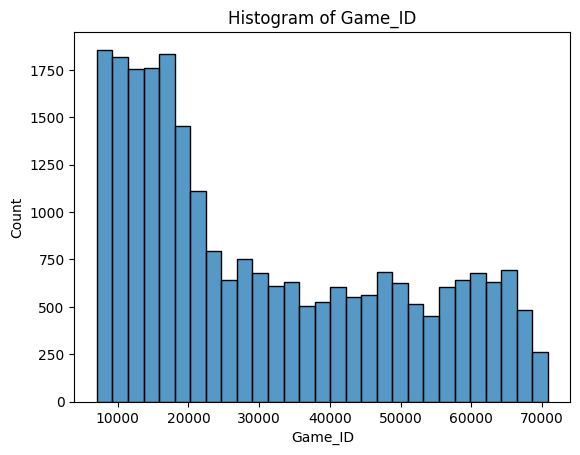

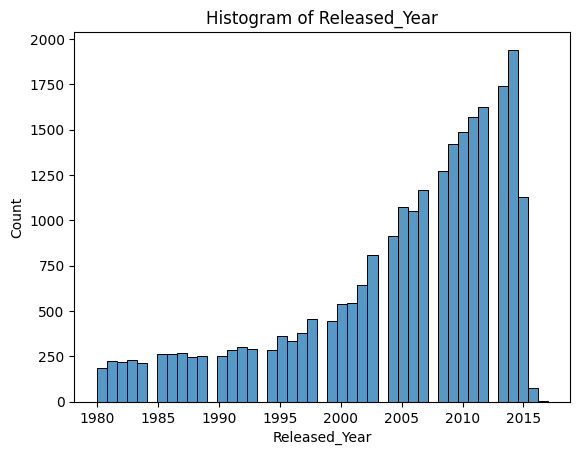

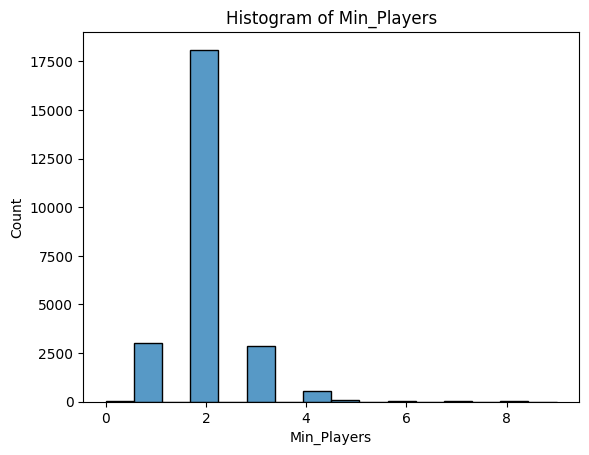

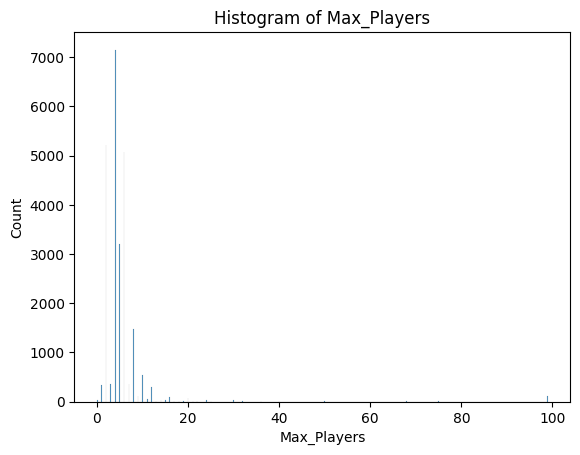

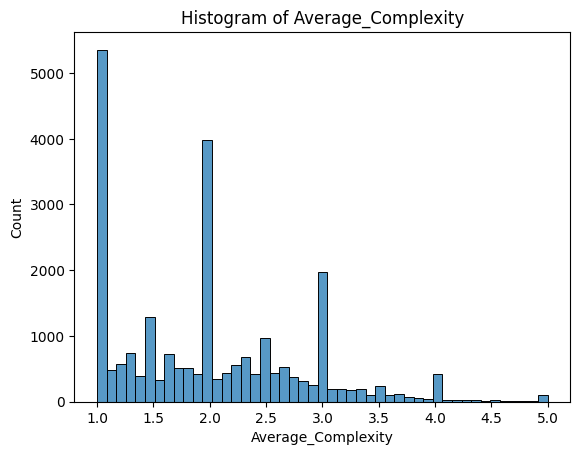

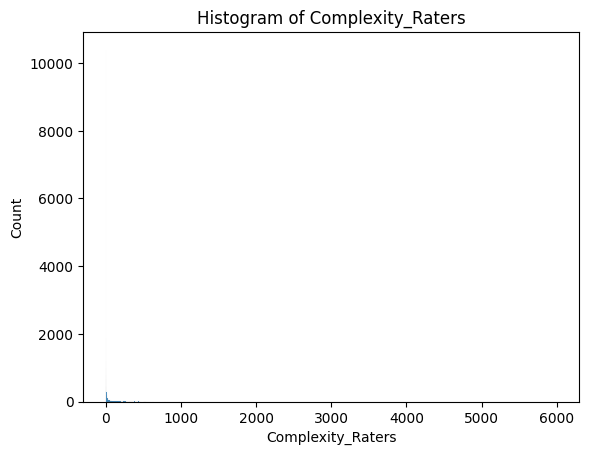

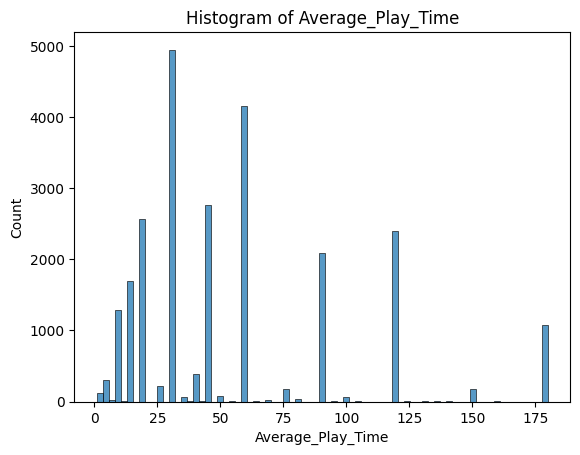

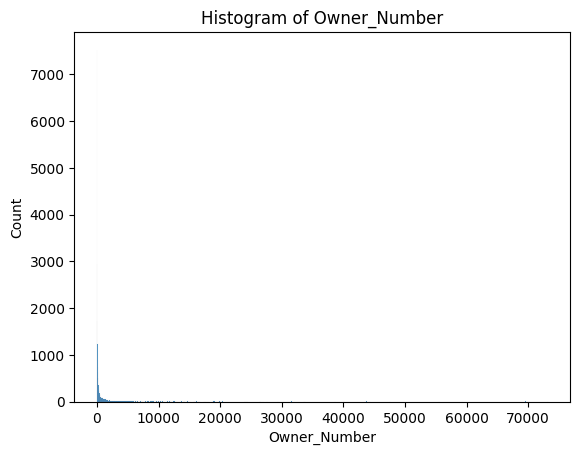

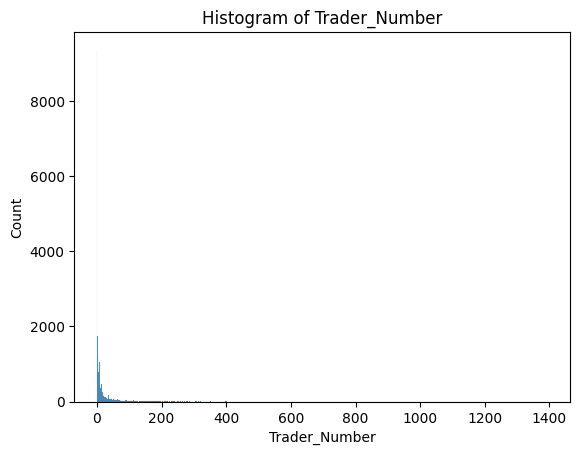

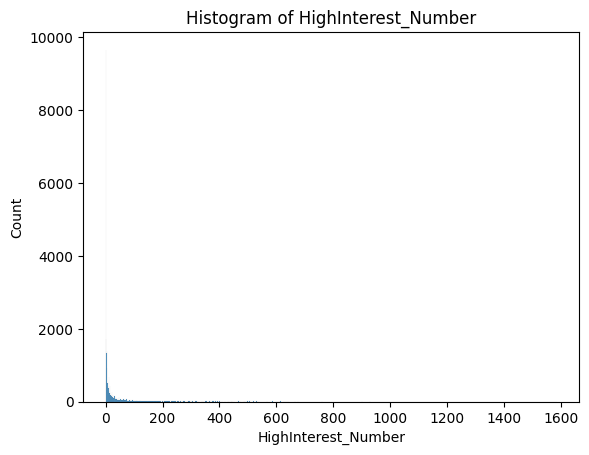

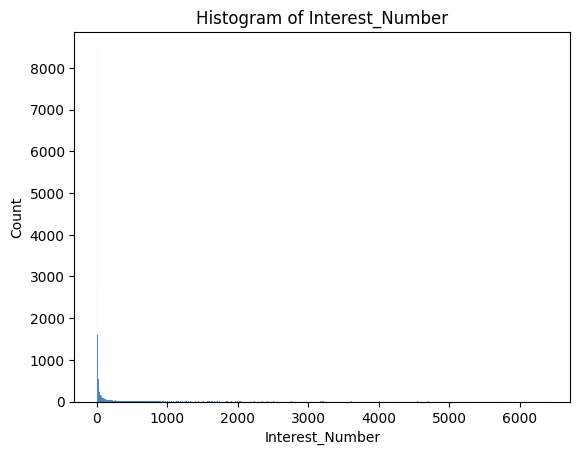

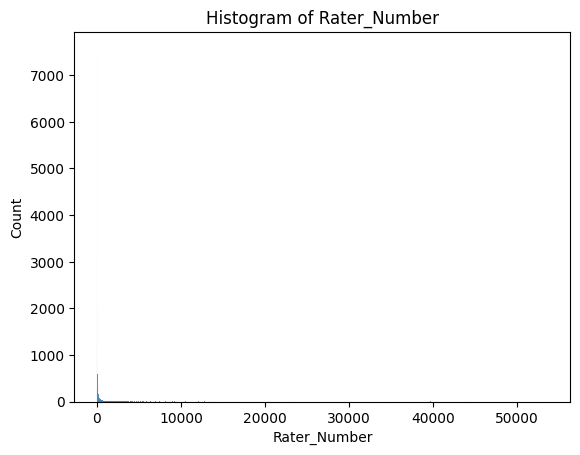

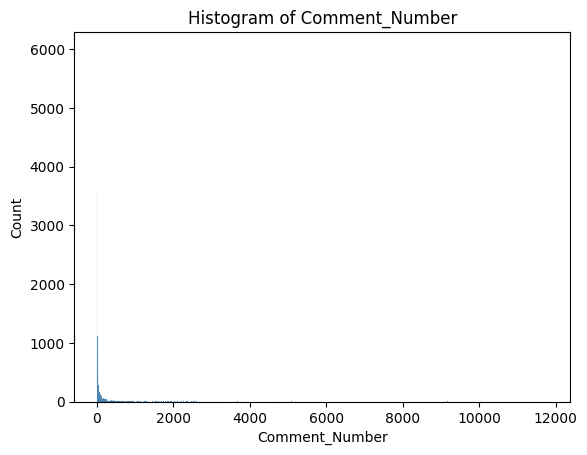

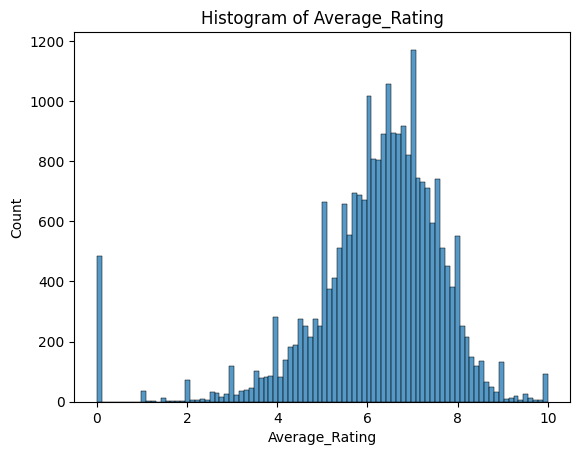

In [11]:
#using seaborn https://seaborn.pydata.org/generated/seaborn.histplot.html
# Get the numerical variables from the dataset
numerical_variables = records.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Print the list of numerical variables
print("Numerical Variables:", numerical_variables)

# Display histograms using seaborn
for variable in numerical_variables:
    sns.histplot(data=records, x=variable)
    plt.title(f"Histogram of {variable}")
    plt.show()


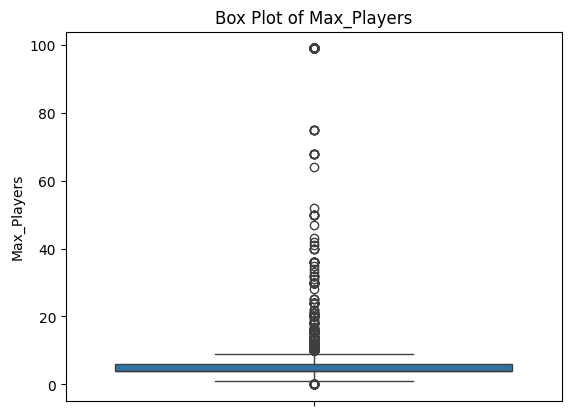

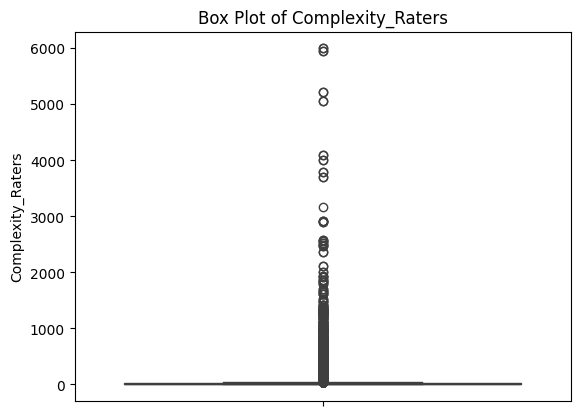

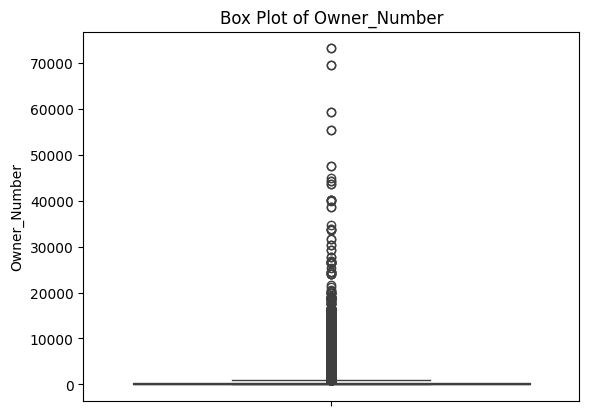

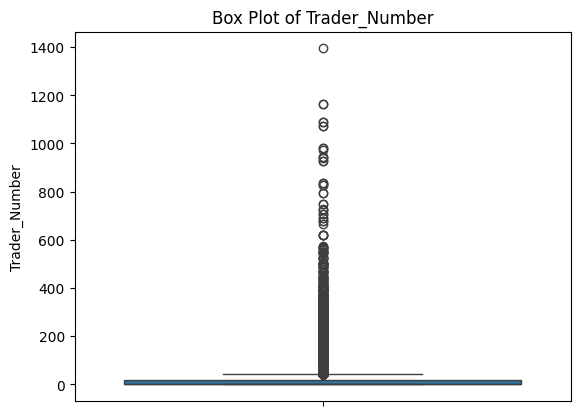

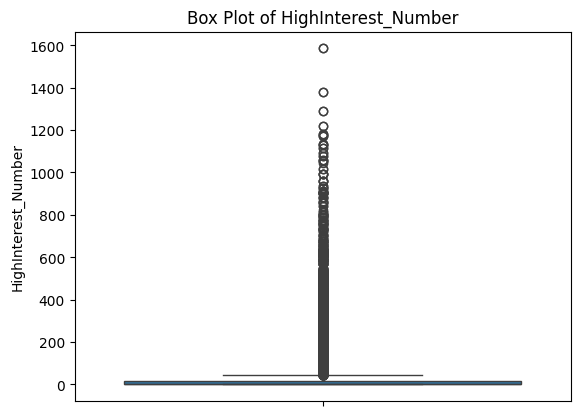

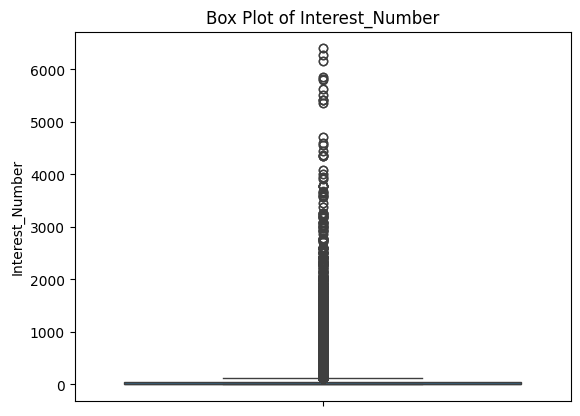

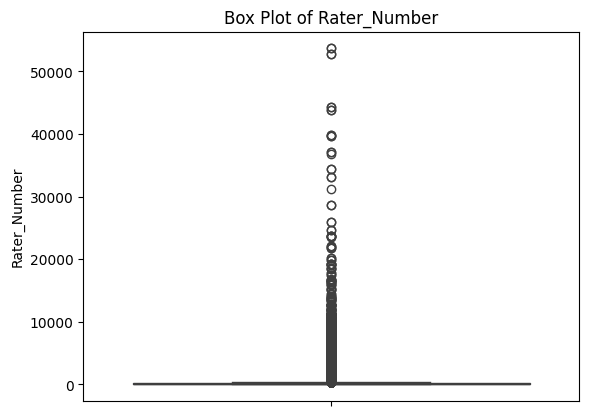

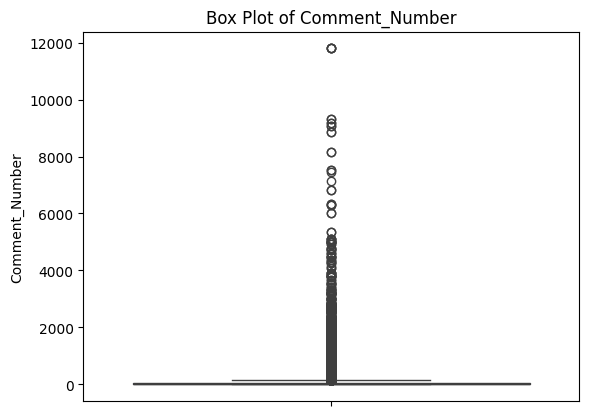

In [12]:
# Select the variables for the box plots
variables = ['Max_Players', 'Complexity_Raters', 'Owner_Number',
             'Trader_Number', 'HighInterest_Number', 'Interest_Number',
             'Rater_Number', 'Comment_Number']

# Create box plots using seaborn
for variable in variables:
    sns.boxplot(data=records, y=variable)
    plt.title(f"Box Plot of {variable}")
    plt.show()

<Axes: xlabel='Game_Type', ylabel='count'>

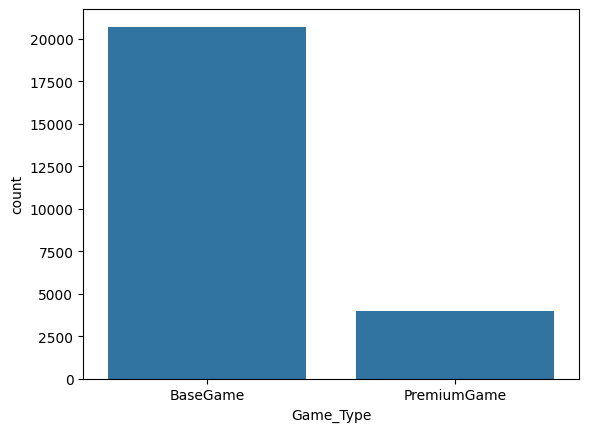

In [13]:
#summarise a categorical variable using a barchart (countplot)
sns.countplot(data=records, x='Game_Type')

<Axes: xlabel='Age_Category', ylabel='count'>

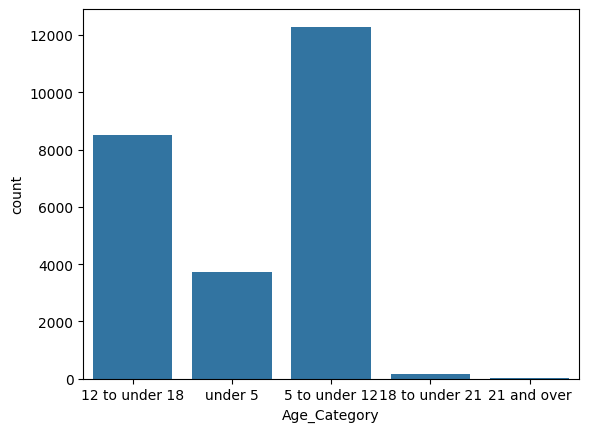

In [14]:
#summarise a categorical variable using a barchart (countplot)
sns.countplot(data=records, x='Age_Category')

In [15]:
#convert categorical data to numerical
def coding_Game_Type(x):
        if x=='BaseGame': return 1
        if x=='PremiumGame': return 2

records['Game_Type_N'] = records['Game_Type'].apply(coding_Game_Type)

records.iloc[9:14]

,Game_ID,Game_Name,Released_Year,Game_Type,Age_Category,Min_Players,Max_Players,Average_Complexity,Complexity_Raters,Average_Play_Time,Owner_Number,Trader_Number,HighInterest_Number,Interest_Number,Rater_Number,Comment_Number,Average_Rating,Game_Type_N
9,42601,The Bob Evans Restaurant Family Game!,2005,BaseGame,5 to under 12,2,8,1.000,1,2,4,0,0,0,2,2,1.050,1
10,23167,A Jumping Frog Game,2000,BaseGame,5 to under 12,2,2,1.000,1,5,9,1,1,0,6,4,5.500,1
11,8043,Wings of War: The Dawn of World War II,2007,BaseGame,12 to under 18,2,6,1.955,134,45,1992,116,62,198,1131,334,6.910,1
12,65555,Pot Farm: The Board Game,2015,BaseGame,18 to under 21,2,4,3.000,1,45,12,0,1,4,4,0,8.500,1
13,21087,National Liberation Front,1983,BaseGame,12 to under 18,2,2,2.667,3,10,31,1,6,11,7,6,6.357,1


In [16]:
#convert categorical data to numerical
def coding_Age_Category(x):
        if x=='under 5': return 1
        if x=='5 to under 12': return 2
        if x=='12 to under 18': return 3
        if x=='18 to under 21': return 4
        if x=='21 and over': return 5

records['Age_Category_N'] = records['Age_Category'].apply(coding_Age_Category)

records.iloc[9:14]

,Game_ID,Game_Name,Released_Year,Game_Type,Age_Category,Min_Players,Max_Players,Average_Complexity,Complexity_Raters,Average_Play_Time,Owner_Number,Trader_Number,HighInterest_Number,Interest_Number,Rater_Number,Comment_Number,Average_Rating,Game_Type_N,Age_Category_N
9,42601,The Bob Evans Restaurant Family Game!,2005,BaseGame,5 to under 12,2,8,1.000,1,2,4,0,0,0,2,2,1.050,1,2
10,23167,A Jumping Frog Game,2000,BaseGame,5 to under 12,2,2,1.000,1,5,9,1,1,0,6,4,5.500,1,2
11,8043,Wings of War: The Dawn of World War II,2007,BaseGame,12 to under 18,2,6,1.955,134,45,1992,116,62,198,1131,334,6.910,1,3
12,65555,Pot Farm: The Board Game,2015,BaseGame,18 to under 21,2,4,3.000,1,45,12,0,1,4,4,0,8.500,1,4
13,21087,National Liberation Front,1983,BaseGame,12 to under 18,2,2,2.667,3,10,31,1,6,11,7,6,6.357,1,3


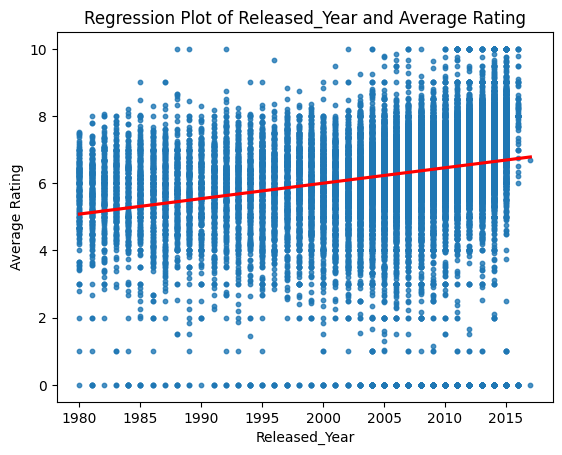

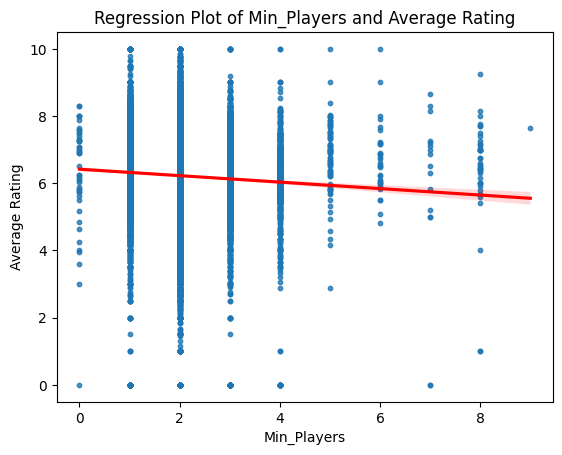

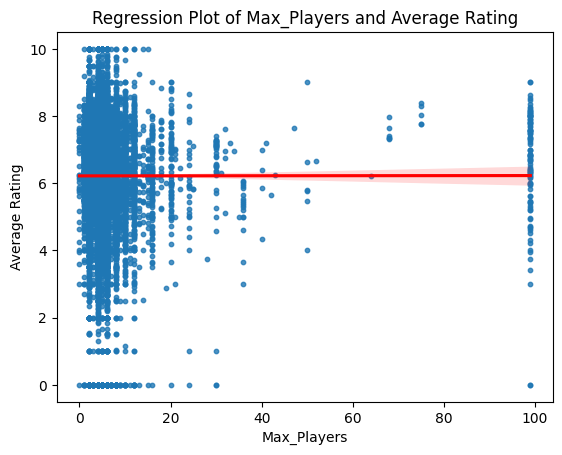

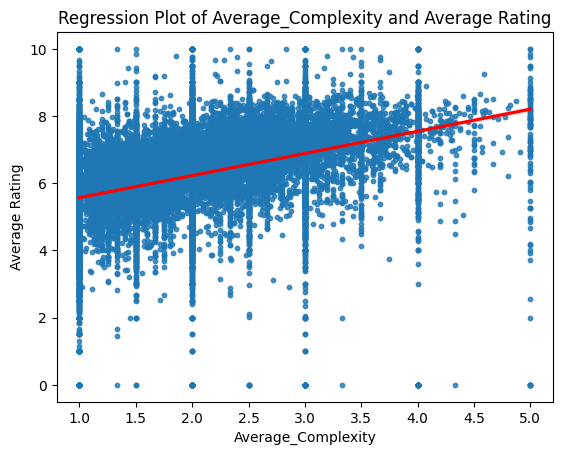

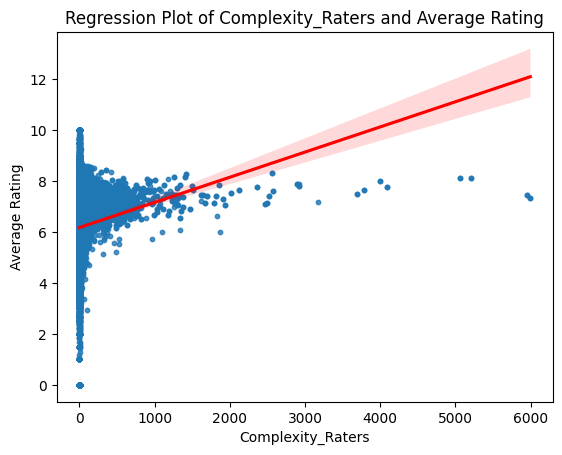

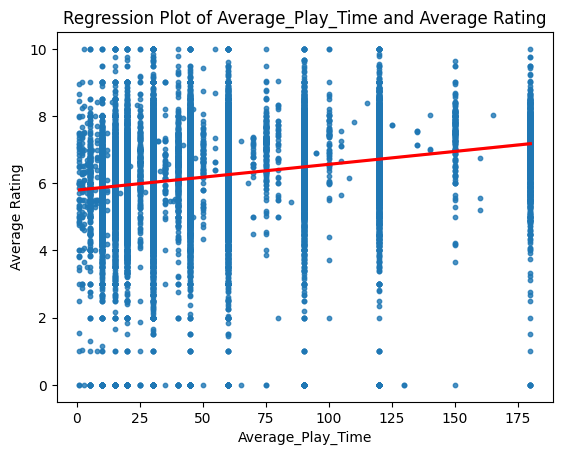

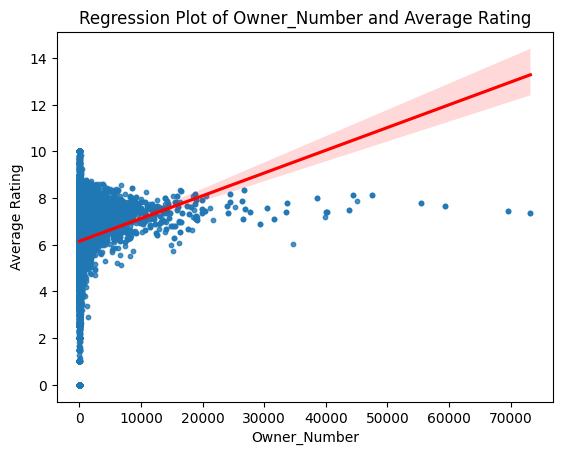

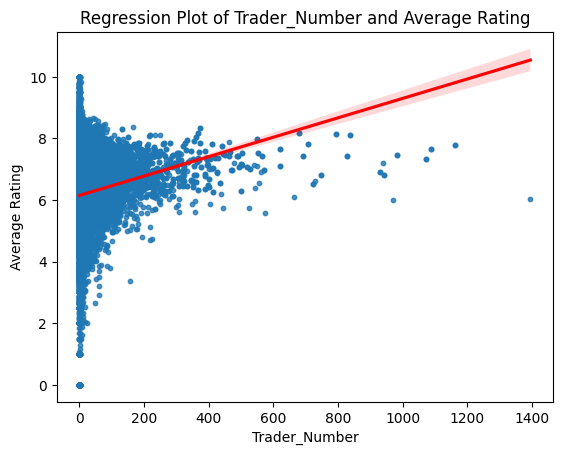

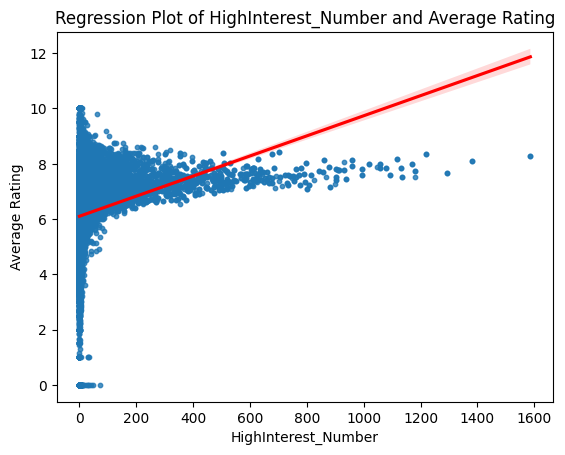

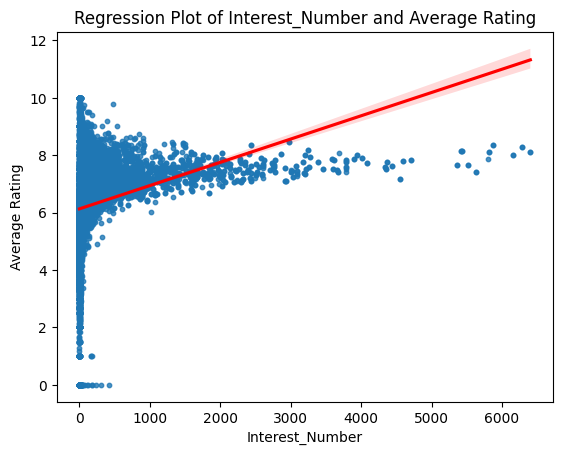

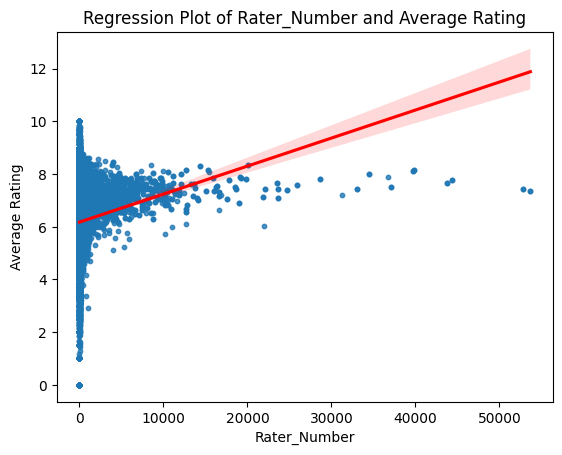

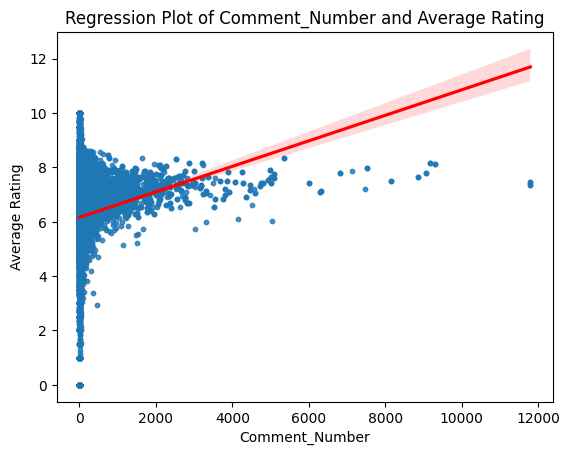

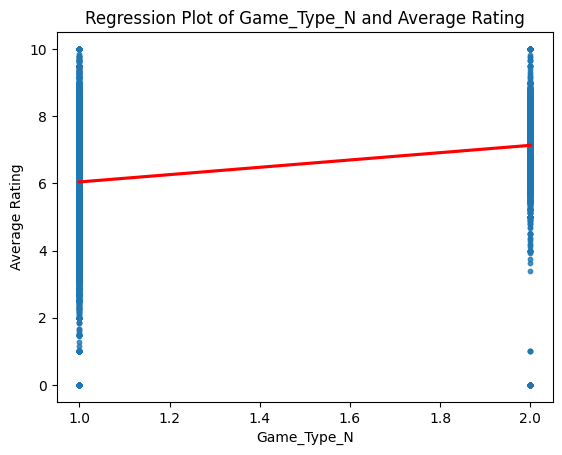

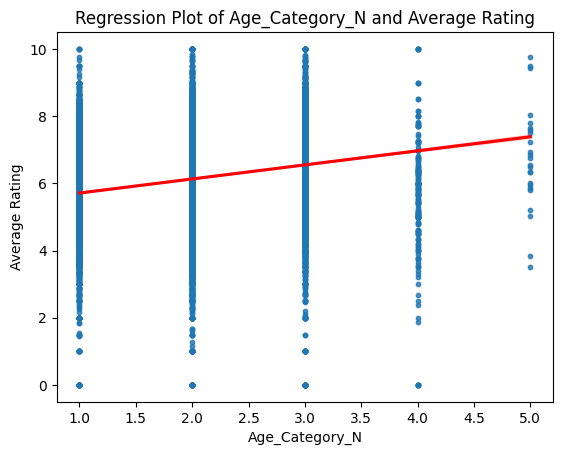

In [17]:
# Get the numerical variables from the dataset (excluding 'Average_Rating')
numerical_variables = records.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_variables.remove('Average_Rating')
numerical_variables.remove('Game_ID')
#
for variable in numerical_variables:
    # Indent the code inside the loop
    sns.regplot(x=variable, y='Average_Rating', data=records, scatter_kws={'s':10}, line_kws={'color':'red'})
    plt.xlabel(variable) # Remove the curly braces around 'variable'
    plt.ylabel('Average Rating')
    plt.title(f"Regression Plot of {variable} and Average Rating") # Correct the typo 'varialbe' to 'variable'
    plt.show()

In [18]:
# Group by Released_Year and calculate the average rating for each year
ratings_over_time = records.groupby('Released_Year')['Average_Rating'].mean()

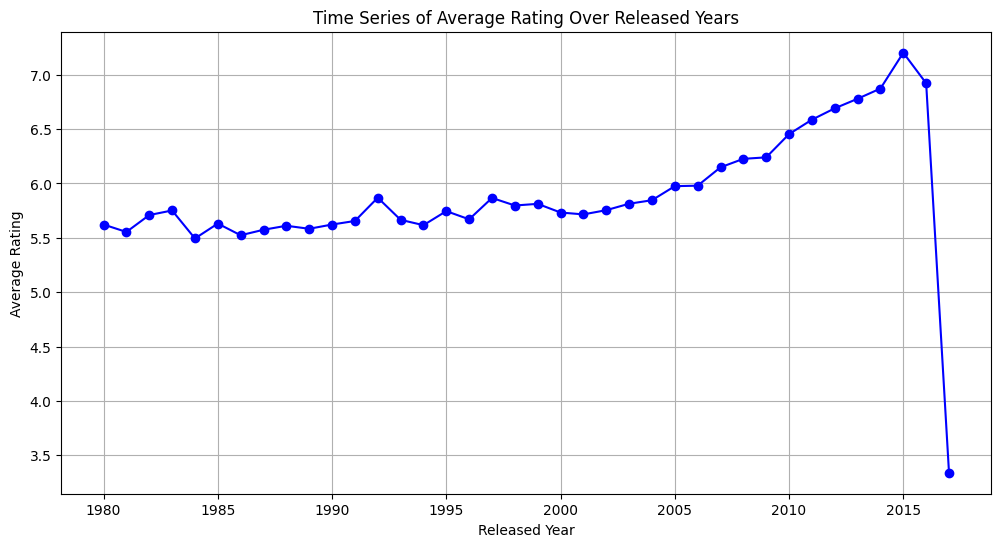

In [19]:
# Create a time series chart of Released Year and Average Rating
plt.figure(figsize=(12, 6))
plt.plot(ratings_over_time.index, ratings_over_time.values, marker='o', linestyle='-', color='b')
plt.title('Time Series of Average Rating Over Released Years')
plt.xlabel('Released Year')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()

In [20]:
#list of numerical variables
num_variables=records.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_variables.remove('Game_ID')

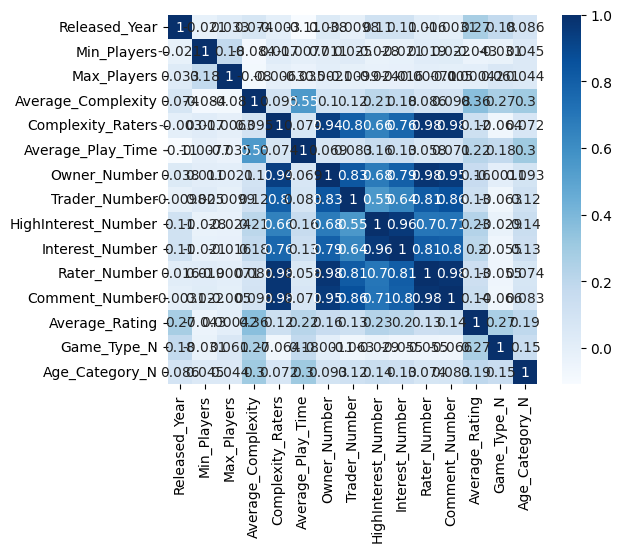

In [21]:
#generate heatmaps to explore relationships
sns.heatmap(records[num_variables].corr(), square=True, cmap='Blues', annot=True)
plt.show()

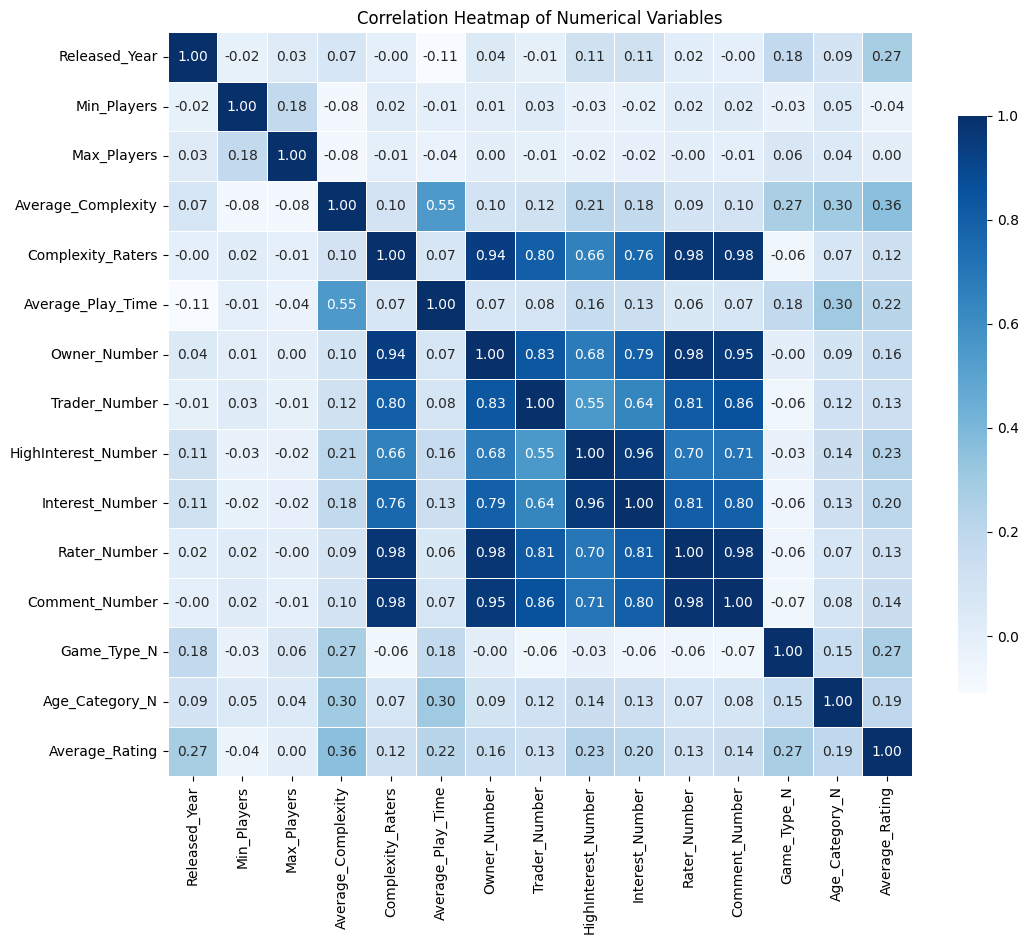

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define your numerical variables
numerical_variables = [
    'Released_Year', 'Min_Players', 'Max_Players', 'Average_Complexity',
    'Complexity_Raters', 'Average_Play_Time', 'Owner_Number', 'Trader_Number',
    'HighInterest_Number', 'Interest_Number', 'Rater_Number', 'Comment_Number',
    'Game_Type_N', 'Age_Category_N', 'Average_Rating'
]

# Create a correlation matrix
corr_matrix = records[numerical_variables].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))  # Adjust the figure size for better readability
sns.heatmap(corr_matrix,
            square=True,
            cmap='Blues',
            annot=True,
            fmt='.2f',       # Format the annotation to 2 decimal places
            linewidths=0.5,  # Add a small line between cells for better separation
            cbar_kws={"shrink": 0.75})  # Adjust color bar size if needed

# Display the plot
plt.title('Correlation Heatmap of Numerical Variables')  # Optional title for the plot
plt.show()

In [23]:
#feature selection
features=['Average_Complexity','Average_Play_Time','HighInterest_Number','Interest_Number','Game_Type_N']
X=records[features]
X.head()

,Average_Complexity,Average_Play_Time,HighInterest_Number,Interest_Number,Game_Type_N
0,3.364,120,293,796,1
1,2.000,60,1,4,1
2,2.000,10,20,49,1
3,2.400,75,36,184,1
4,3.000,120,1,3,1


In [24]:
#specify the label
y=records['Average_Rating']
y.head()

,Average_Rating
0,7.519
1,7.500
2,6.488
3,7.661
4,7.500


In [25]:
from sklearn.model_selection import train_test_split # Import train_test_split function

# Split dataset into training set 80% and test set 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2023)

#inspect the split datasets
print(X_train.head())
print(y_train.head())

print('Training dataset size:',X_train.shape)
print('Test dataset size:',X_test.shape)

       Average_Complexity  Average_Play_Time  HighInterest_Number  \
897                 1.250                 20                    1   
18369               1.000                 60                    0   
23934               1.000                 30                    1   
1561                1.000                120                    0   
15516               1.833                 60                  319   

       Interest_Number  Game_Type_N  
897                 12            1  
18369                1            1  
23934                3            1  
1561                 2            1  
15516              930            1  
897     5.883
18369   3.444
23934   5.352
1561    4.333
15516   6.873
Name: Average_Rating, dtype: float64
Training dataset size: (19779, 5)
Test dataset size: (4945, 5)


In [26]:
from sklearn.model_selection import train_test_split # Import train_test_split function
#import linear_model
from sklearn import linear_model

In [28]:
#linear regression model
reg = linear_model.LinearRegression()

In [29]:
# Train a Regression model (regressor) with the training dataset
reg=reg.fit(X_train, y_train)

In [30]:
#Make predictions for the test dataset
y_pred = reg.predict(X_test)

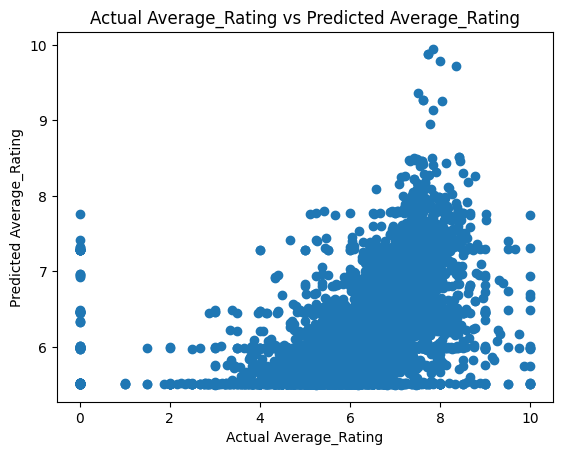

In [33]:
#Inspect the predictions and the original labels
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Average_Rating")
plt.ylabel("Predicted Average_Rating")
plt.title("Actual Average_Rating vs Predicted Average_Rating")
plt.show()

In [34]:
#set the formatting for floating numbers
pd.set_option('display.float_format', lambda x: '%.0f' % x)
Average_Complexity=X_test['Average_Complexity']
#inspection
inspection=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
inspection=pd.DataFrame({'Average_Complexity':Average_Complexity, 'Actual':y_test, 'Predicted':y_pred})
inspection.head(20)

,Average_Complexity,Actual,Predicted
3311,1,6,6
11127,2,7,7
9613,1,7,6
14812,3,7,6
22637,1,7,6
14838,2,4,6
10204,2,7,6
22542,1,6,6
17153,1,6,6
8585,1,7,6


In [35]:
pd.set_option('display.float_format', lambda x: '%.0f' % x)
Average_Play_Time=X_test['Average_Play_Time']
#inspection
inspection=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
inspection=pd.DataFrame({'Average_Play_Time':Average_Play_Time, 'Actual':y_test, 'Predicted':y_pred})
inspection.head(20)

,Average_Play_Time,Actual,Predicted
3311,120,6,6
11127,75,7,7
9613,15,7,6
14812,20,7,6
22637,10,7,6
14838,90,4,6
10204,20,7,6
22542,10,6,6
17153,30,6,6
8585,5,7,6


In [36]:
pd.set_option('display.float_format', lambda x: '%.0f' % x)
HighInterest_Number=X_test['HighInterest_Number']
#inspection
inspection=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
inspection=pd.DataFrame({'HighInterest_Number':HighInterest_Number, 'Actual':y_test, 'Predicted':y_pred})
inspection.head(20)

,HighInterest_Number,Actual,Predicted
3311,1,6,6
11127,18,7,7
9613,170,7,6
14812,1,7,6
22637,20,7,6
14838,3,4,6
10204,13,7,6
22542,0,6,6
17153,1,6,6
8585,1,7,6


In [37]:
pd.set_option('display.float_format', lambda x: '%.0f' % x)
Interest_Number=X_test['Interest_Number']
#inspection
inspection=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
inspection=pd.DataFrame({'Interest_Number':Interest_Number, 'Actual':y_test, 'Predicted':y_pred})
inspection.head(20)

,Interest_Number,Actual,Predicted
3311,4,6,6
11127,51,7,7
9613,584,7,6
14812,0,7,6
22637,47,7,6
14838,6,4,6
10204,41,7,6
22542,1,6,6
17153,6,6,6
8585,15,7,6


In [38]:
pd.set_option('display.float_format', lambda x: '%.0f' % x)
Game_Type_N=X_test['Game_Type_N']
#inspection
inspection=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
inspection=pd.DataFrame({'Game_Type_N':Game_Type_N, 'Actual':y_test, 'Predicted':y_pred})
inspection.head(20)

,Game_Type_N,Actual,Predicted
3311,1,6,6
11127,2,7,7
9613,1,7,6
14812,1,7,6
22637,1,7,6
14838,1,4,6
10204,1,7,6
22542,1,6,6
17153,1,6,6
8585,1,7,6


In [39]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.2f}")

R-squared: 0.19


In [40]:
from sklearn.metrics import mean_absolute_error

# Calculate and print the mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.0f}")

Mean Absolute Error: 1


In [41]:
from sklearn.metrics import mean_squared_error

# Calculate and print the root mean square error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error: {rmse:.0f}")

Root Mean Square Error: 1


In [42]:
#Examine the performance using the descriptive stats
inspection['Actual'].describe()

,Actual
count,4945
mean,6
std,2
min,0
25%,6
50%,6
75%,7
max,10


In [43]:
#Examine the descriptive stats of predicted value
inspection['Predicted'].describe()

,Predicted
count,4945
mean,6
std,1
min,5
25%,6
50%,6
75%,7
max,10


In [44]:
# Print the features and their coefficients
for feature, coef in zip(features, reg.coef_):
    print(f'{feature}: {coef:.5f}')

Average_Complexity: 0.47067
Average_Play_Time: 0.00030
HighInterest_Number: 0.00434
Interest_Number: -0.00039
Game_Type_N: 0.82246


In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [46]:
# Ensure all data in X is numeric
X = X.apply(pd.to_numeric, errors='coerce')

In [47]:
# Convert boolean columns to integers
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

In [48]:
# Add intercept for VIF calculation
X_vif = X.copy()
X_vif['intercept'] = 1

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["variables"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Print VIFs to two decimal places
for index, row in vif_data.iterrows():
    print(f'{row["variables"]}: {row["VIF"]:.2f}')

Average_Complexity: 1.53
Average_Play_Time: 1.44
HighInterest_Number: 12.78
Interest_Number: 12.66
Game_Type_N: 1.09
intercept: 13.66
